# Notebook15 — RL-Based Policy Optimization for CHO Digital Twin

---

## Goal

Notebook14v2 created a dynamic cellular-state simulator.

It generated trajectories with:

state → action → transition → reward → next state

Notebook15 uses those trajectories to train a simple reinforcement-learning-style policy.

The goal is to ask:

Can an algorithm learn which process action should be applied for each cellular state?

---

## Input

This notebook uses the Notebook14v2 output:

data/synthetic/digital_twin/notebook14_v2_dynamic_policy_trajectory_5000_legacy.csv

Each row represents one simulated clone-process-policy-time state.

---

## Available actions

The RL agent can choose from:

- no_action
- adaptive_feed
- mild_temp_shift
- perfusion_rescue
- stress_mitigation

---

## What this notebook adds

Notebook14v2 compared hand-written policies.

Notebook15 learns a policy from simulated experience.

This moves the project closer to:

- digital twin decision support
- closed-loop process control
- reinforcement learning
- self-driving laboratory simulation

---

## Important note

This is not yet a full industrial RL system.

This is an offline Q-learning prototype trained on synthetic digital-twin trajectories.

Its purpose is to test whether the simulator can support action-learning logic.

## Section 1 — Import libraries

This section loads the libraries required for offline reinforcement-learning-style policy learning.

No external RL package is used.

The Q-learning logic is implemented directly so the method stays transparent and easy to inspect.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Section 2 — Load Notebook14v2 dynamic trajectory output

Notebook15 starts from the dynamic trajectory table generated by Notebook14v2.

This file already contains:

- clone-process candidate ID
- policy used in Notebook14v2
- pseudo-time
- action
- dynamic cellular state
- reward
- dynamic regime name

This is the experience dataset used for offline Q-learning.

In [2]:
# --------------------------------------------------
# Section 2 — Load Notebook14v2 dynamic trajectory output
# --------------------------------------------------

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError(
        "Could not find project root containing data/synthetic"
    )


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

INPUT_PATH = (
    ROOT
    / "data"
    / "synthetic"
    / "digital_twin"
    / f"notebook14_v2_dynamic_policy_trajectory_{n_clones}_{scenario}.csv"
)

trajectory = pd.read_csv(INPUT_PATH)

print("ROOT:", ROOT)
print("INPUT_PATH:", INPUT_PATH)
print("Trajectory shape:", trajectory.shape)

display(trajectory.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
INPUT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_v2_dynamic_policy_trajectory_5000_legacy.csv
Trajectory shape: (8280, 19)


,clone_process_id,policy,pseudo_time,action,cellular_archetype,rescue_potential,productivity_state,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden,reward,dynamic_latent_1,dynamic_latent_2,dynamic_regime,regime_name
0,0,no_action,0,no_action,Quality-Adapted,0.584229,0.995759,0.591557,0.376073,0.673473,0.439010,0.768677,0.645732,0.558729,0.363210,2.008582,5.820162,1,Stress_HighRisk
1,0,no_action,1,no_action,Quality-Adapted,0.584229,0.973849,0.626745,0.394300,0.691700,0.479357,0.749948,0.627002,0.597353,0.336872,2.463318,5.757630,1,Stress_HighRisk
2,0,no_action,2,no_action,Quality-Adapted,0.584229,0.958454,0.662922,0.437097,0.734498,0.501534,0.730245,0.607299,0.630533,0.314615,2.959081,5.744637,1,Stress_HighRisk
3,0,no_action,3,no_action,Quality-Adapted,0.584229,0.927426,0.712968,0.465041,0.762442,0.537312,0.710185,0.587240,0.674841,0.282941,3.516977,5.664876,1,Stress_HighRisk
4,0,no_action,4,no_action,Quality-Adapted,0.584229,0.906987,0.745394,0.492284,0.789684,0.584014,0.699193,0.576247,0.710406,0.259648,3.979673,5.628563,1,Stress_HighRisk


## Section 3 — Validate required columns

This section checks whether the Notebook14v2 trajectory table contains all required columns.

Notebook15 requires:

- state variables
- action
- reward
- pseudo-time
- clone-process ID
- regime labels

If any of these are missing, the RL training cannot proceed correctly.

In [3]:
# --------------------------------------------------
# Section 3 — Validate required columns
# --------------------------------------------------

state_cols = [
    "productivity_state",
    "integrated_burden",
    "oxidative_stress",
    "er_stress_burden",
    "stress_failure_risk",
    "galactosylation",
    "sialylation",
    "overflow_burden",
]

required_cols = [
    "clone_process_id",
    "policy",
    "pseudo_time",
    "action",
    "reward",
    *state_cols,
]

optional_cols = [
    "dynamic_regime",
    "regime_name",
    "cellular_archetype",
    "rescue_potential",
]

missing = [c for c in required_cols if c not in trajectory.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

print("All required columns are available.")

available_optional = [c for c in optional_cols if c in trajectory.columns]
print("Available optional columns:", available_optional)

display(trajectory[required_cols + available_optional].head())

All required columns are available.
Available optional columns: ['dynamic_regime', 'regime_name', 'cellular_archetype', 'rescue_potential']


,clone_process_id,policy,pseudo_time,action,reward,productivity_state,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden,dynamic_regime,regime_name,cellular_archetype,rescue_potential
0,0,no_action,0,no_action,0.363210,0.995759,0.591557,0.376073,0.673473,0.439010,0.768677,0.645732,0.558729,1,Stress_HighRisk,Quality-Adapted,0.584229
1,0,no_action,1,no_action,0.336872,0.973849,0.626745,0.394300,0.691700,0.479357,0.749948,0.627002,0.597353,1,Stress_HighRisk,Quality-Adapted,0.584229
2,0,no_action,2,no_action,0.314615,0.958454,0.662922,0.437097,0.734498,0.501534,0.730245,0.607299,0.630533,1,Stress_HighRisk,Quality-Adapted,0.584229
3,0,no_action,3,no_action,0.282941,0.927426,0.712968,0.465041,0.762442,0.537312,0.710185,0.587240,0.674841,1,Stress_HighRisk,Quality-Adapted,0.584229
4,0,no_action,4,no_action,0.259648,0.906987,0.745394,0.492284,0.789684,0.584014,0.699193,0.576247,0.710406,1,Stress_HighRisk,Quality-Adapted,0.584229


## Section 4 — Inspect state and reward distributions

Before training an RL policy, we inspect the input state space.

This helps confirm that:

- state variables are bounded in reasonable ranges
- reward has variation
- actions are present
- regimes are available for biological interpretation

In [4]:
# --------------------------------------------------
# Section 4 — Inspect state and reward distributions
# --------------------------------------------------

display(
    trajectory[
        state_cols + ["reward"]
    ]
    .describe()
    .T
    .round(3)
)

print("Action counts:")
display(trajectory["action"].value_counts())

if "regime_name" in trajectory.columns:
    print("Regime counts:")
    display(trajectory["regime_name"].value_counts())

,count,mean,std,min,25%,50%,75%,max
productivity_state,8280.0,0.144,0.170,0.000,0.026,0.084,0.204,0.996
integrated_burden,8280.0,0.191,0.168,0.000,0.016,0.183,0.307,1.000
oxidative_stress,8280.0,0.265,0.189,0.000,0.103,0.273,0.399,1.000
er_stress_burden,8280.0,0.251,0.199,0.000,0.061,0.254,0.393,1.000
stress_failure_risk,8280.0,0.279,0.210,0.000,0.103,0.271,0.422,1.000
galactosylation,8280.0,0.751,0.191,0.024,0.631,0.761,0.916,1.000
sialylation,8280.0,0.691,0.216,0.083,0.516,0.690,0.891,1.000
overflow_burden,8280.0,0.244,0.169,0.000,0.108,0.249,0.365,1.000
reward,8280.0,0.216,0.114,-0.157,0.134,0.205,0.295,0.575


Action counts:


action
no_action            3414
adaptive_feed        1846
perfusion_rescue     1011
mild_temp_shift      1006
stress_mitigation    1003
Name: count, dtype: int64

Regime counts:


regime_name
Burdened_LowQuality    3180
Adaptive_Quality       2469
Productive_Rescued     1994
Stress_HighRisk         637
Name: count, dtype: int64

## Section 5 — Define action space

The RL agent can choose among the process actions introduced in Notebook14v2.

These actions represent simplified upstream process interventions.

The goal is to learn which action is best for each cellular state.

In [5]:
# --------------------------------------------------
# Section 5 — Define action space
# --------------------------------------------------

actions = [
    "no_action",
    "adaptive_feed",
    "mild_temp_shift",
    "perfusion_rescue",
    "stress_mitigation",
]

action_to_idx = {a: i for i, a in enumerate(actions)}
idx_to_action = {i: a for a, i in action_to_idx.items()}

print(action_to_idx)

unknown_actions = sorted(set(trajectory["action"]) - set(actions))

if unknown_actions:
    raise ValueError(f"Unknown actions found: {unknown_actions}")

{'no_action': 0, 'adaptive_feed': 1, 'mild_temp_shift': 2, 'perfusion_rescue': 3, 'stress_mitigation': 4}


## Section 6 — Build discrete RL state representation

Q-learning uses a discrete state table.

However, the cellular variables are continuous.

This section converts key biological variables into discrete bins:

- productivity
- burden
- failure risk
- galactosylation
- overflow burden

The resulting state label represents the cellular condition in a simplified form.

Example:

high productivity + low burden + low risk

becomes a different RL state than:

low productivity + high burden + high risk.

In [6]:
# --------------------------------------------------
# Section 6 — Build discrete RL state representation
# --------------------------------------------------

bin_cols = {
    "productivity_state": "prod_bin",
    "integrated_burden": "burden_bin",
    "stress_failure_risk": "risk_bin",
    "galactosylation": "gal_bin",
    "overflow_burden": "overflow_bin",
}

n_bins = 4

trajectory_rl = trajectory.copy()

for col, bin_col in bin_cols.items():
    trajectory_rl[bin_col] = pd.qcut(
        trajectory_rl[col],
        q=n_bins,
        labels=False,
        duplicates="drop"
    ).astype(int)

trajectory_rl["rl_state"] = (
    "P" + trajectory_rl["prod_bin"].astype(str)
    + "_B" + trajectory_rl["burden_bin"].astype(str)
    + "_R" + trajectory_rl["risk_bin"].astype(str)
    + "_G" + trajectory_rl["gal_bin"].astype(str)
    + "_O" + trajectory_rl["overflow_bin"].astype(str)
)

print("Number of discrete RL states:", trajectory_rl["rl_state"].nunique())

display(
    trajectory_rl[
        [
            "rl_state",
            *bin_cols.values(),
            "action",
            "reward",
        ]
    ].head()
)

Number of discrete RL states: 549


,rl_state,prod_bin,burden_bin,risk_bin,gal_bin,overflow_bin,action,reward
0,P3_B3_R3_G2_O3,3,3,3,2,3,no_action,0.363210
1,P3_B3_R3_G1_O3,3,3,3,1,3,no_action,0.336872
2,P3_B3_R3_G1_O3,3,3,3,1,3,no_action,0.314615
3,P3_B3_R3_G1_O3,3,3,3,1,3,no_action,0.282941
4,P3_B3_R3_G1_O3,3,3,3,1,3,no_action,0.259648


## Section 7 — Encode RL states

Each unique discrete state is mapped to an integer index.

This allows us to build a Q-table.

The Q-table has:

rows = states

columns = actions

Each cell estimates the long-term value of taking one action from one state.

In [7]:
# --------------------------------------------------
# Section 7 — Encode RL states
# --------------------------------------------------

unique_states = sorted(trajectory_rl["rl_state"].unique())

state_to_idx = {s: i for i, s in enumerate(unique_states)}
idx_to_state = {i: s for s, i in state_to_idx.items()}

n_states = len(unique_states)
n_actions = len(actions)

print("n_states:", n_states)
print("n_actions:", n_actions)
print("Q-table shape:", (n_states, n_actions))

n_states: 549
n_actions: 5
Q-table shape: (549, 5)


## Section 8 — Construct offline transition dataset

This section converts the Notebook14v2 trajectory table into RL transitions.

Each transition contains:

current state → action → reward → next state

The transitions are extracted within each clone-process-policy trajectory.

This creates the experience dataset used by offline Q-learning.

In [8]:
# --------------------------------------------------
# Section 8 — Construct offline transition dataset
# --------------------------------------------------

sort_cols = [
    "clone_process_id",
    "policy",
    "pseudo_time",
]

trajectory_rl = trajectory_rl.sort_values(sort_cols).reset_index(drop=True)

transitions = []

group_cols = [
    "clone_process_id",
    "policy",
]

for _, grp in trajectory_rl.groupby(group_cols):
    grp = grp.sort_values("pseudo_time").reset_index(drop=True)

    for i in range(len(grp) - 1):
        current_row = grp.loc[i]
        next_row = grp.loc[i + 1]

        transitions.append({
            "state": current_row["rl_state"],
            "action": next_row["action"],
            "reward": float(next_row["reward"]),
            "next_state": next_row["rl_state"],
            "policy": next_row["policy"],
            "pseudo_time": int(next_row["pseudo_time"]),
            "clone_process_id": int(next_row["clone_process_id"]),
            "regime_name": next_row["regime_name"] if "regime_name" in grp.columns else None,
        })

transitions_df = pd.DataFrame(transitions)

print("Number of transitions:", len(transitions_df))
display(transitions_df.head())

Number of transitions: 7728


,state,action,reward,next_state,policy,pseudo_time,clone_process_id,regime_name
0,P3_B3_R3_G1_O3,no_action,0.322897,P3_B3_R3_G1_O3,adaptive_feed,1,0,Stress_HighRisk
1,P3_B3_R3_G1_O3,no_action,0.301309,P3_B3_R3_G1_O3,adaptive_feed,2,0,Stress_HighRisk
2,P3_B3_R3_G1_O3,no_action,0.280606,P3_B3_R3_G1_O3,adaptive_feed,3,0,Stress_HighRisk
3,P3_B3_R3_G1_O3,adaptive_feed,0.257557,P3_B3_R3_G1_O3,adaptive_feed,4,0,Stress_HighRisk
4,P3_B3_R3_G1_O3,adaptive_feed,0.240496,P3_B3_R3_G1_O3,adaptive_feed,5,0,Stress_HighRisk


## Section 9 — Check transition coverage

Offline RL depends on the experience available in the dataset.

This section checks how many state-action combinations are observed.

If many actions are missing for many states, the learned policy should be interpreted carefully.

This is a normal limitation of offline RL.

State-action pairs observed: 1306
Mean observed actions per state: 2.43


n_observed_actions
1    191
2    120
3     93
4     74
5     60
Name: count, dtype: int64

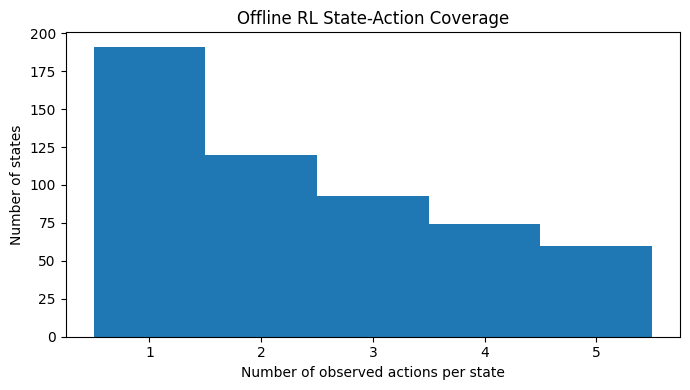

In [9]:
# --------------------------------------------------
# Section 9 — Check transition coverage
# --------------------------------------------------

state_action_counts = (
    transitions_df
    .groupby(["state", "action"])
    .size()
    .reset_index(name="count")
)

coverage = (
    state_action_counts
    .groupby("state")["action"]
    .nunique()
    .reset_index(name="n_observed_actions")
)

print("State-action pairs observed:", len(state_action_counts))
print("Mean observed actions per state:", coverage["n_observed_actions"].mean().round(2))

display(coverage["n_observed_actions"].value_counts().sort_index())

plt.figure(figsize=(7, 4))
plt.hist(coverage["n_observed_actions"], bins=np.arange(1, n_actions + 2) - 0.5)
plt.xlabel("Number of observed actions per state")
plt.ylabel("Number of states")
plt.title("Offline RL State-Action Coverage")
plt.xticks(range(1, n_actions + 1))
plt.tight_layout()
plt.show()

## Section 10 — Initialize Q-table

The Q-table stores the estimated long-term value of each action in each state.

Initially, all values are zero.

During training, the table is updated using the Bellman equation:

current value ← observed reward + discounted future value

In [10]:
# --------------------------------------------------
# Section 10 — Initialize Q-table
# --------------------------------------------------

Q = np.zeros((n_states, n_actions), dtype=float)

print("Q-table initialized:", Q.shape)

Q-table initialized: (549, 5)


## Section 11 — Train offline Q-learning model

This section trains a simple Q-learning model using the transitions extracted from Notebook14v2.

The agent learns from simulated experience.

Key parameters:

- alpha: learning rate
- gamma: future reward discount factor
- epochs: number of passes through the transition dataset

The output is a Q-table estimating the long-term value of each state-action pair.

Training complete.
Final mean observed reward: 0.2198


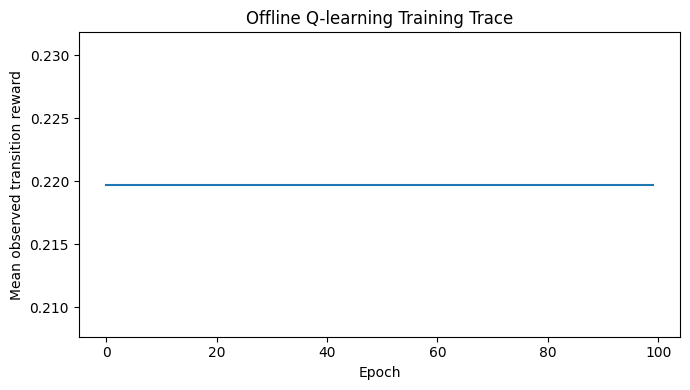

In [11]:
# --------------------------------------------------
# Section 11 — Train offline Q-learning model
# --------------------------------------------------

alpha = 0.10
gamma = 0.95
epochs = 100

rng = np.random.default_rng(42)

training_rewards = []

transition_records = transitions_df.to_dict("records")

for epoch in range(epochs):
    rng.shuffle(transition_records)

    epoch_reward = []

    for tr in transition_records:
        s = tr["state"]
        a = tr["action"]
        r = tr["reward"]
        s2 = tr["next_state"]

        s_idx = state_to_idx[s]
        a_idx = action_to_idx[a]
        s2_idx = state_to_idx[s2]

        td_target = r + gamma * np.max(Q[s2_idx])
        td_error = td_target - Q[s_idx, a_idx]

        Q[s_idx, a_idx] += alpha * td_error

        epoch_reward.append(r)

    training_rewards.append(np.mean(epoch_reward))

print("Training complete.")
print("Final mean observed reward:", round(training_rewards[-1], 4))

plt.figure(figsize=(7, 4))
plt.plot(training_rewards)
plt.xlabel("Epoch")
plt.ylabel("Mean observed transition reward")
plt.title("Offline Q-learning Training Trace")
plt.tight_layout()
plt.show()

## Section 12 — Extract learned policy

After training, the best action for each state is selected from the Q-table.

This produces the learned RL policy.

For each cellular state, the policy recommends the action with the highest estimated long-term value.

In [12]:
# --------------------------------------------------
# Section 12 — Extract learned policy
# --------------------------------------------------

best_action_idx = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

policy_df = pd.DataFrame({
    "rl_state": unique_states,
    "best_action": [idx_to_action[i] for i in best_action_idx],
    "state_value": state_values,
})

display(policy_df.head(20))

,rl_state,best_action,state_value
0,P0_B0_R0_G0_O0,no_action,8.485563
1,P0_B0_R0_G1_O0,perfusion_rescue,9.020984
2,P0_B0_R0_G1_O1,mild_temp_shift,9.191952
3,P0_B0_R0_G2_O0,no_action,9.326529
4,P0_B0_R0_G3_O0,perfusion_rescue,9.438563
5,P0_B0_R0_G3_O1,mild_temp_shift,9.190208
6,P0_B0_R0_G3_O2,stress_mitigation,0.280838
7,P0_B0_R1_G0_O0,perfusion_rescue,8.637880
8,P0_B0_R1_G0_O1,no_action,8.354980
9,P0_B0_R1_G1_O0,perfusion_rescue,8.948759


## Section 13 — Learned action preference distribution

This section summarizes how often each action is selected by the learned policy.

This tells us what the RL agent generally prefers across the cellular-state landscape.

best_action
no_action            126
adaptive_feed        119
mild_temp_shift       81
perfusion_rescue     134
stress_mitigation     89
Name: count, dtype: int64

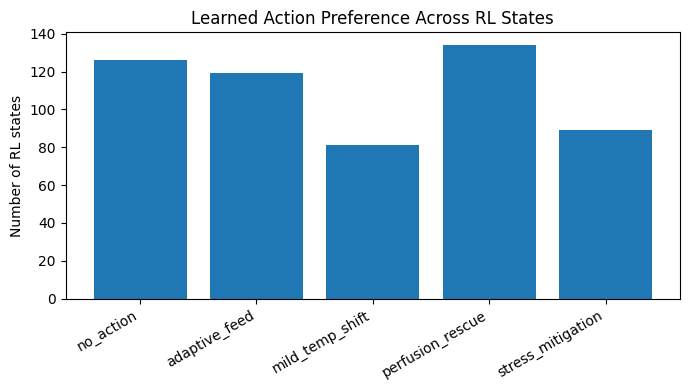

In [13]:
# --------------------------------------------------
# Section 13 — Learned action preference distribution
# --------------------------------------------------

action_pref = (
    policy_df["best_action"]
    .value_counts()
    .reindex(actions)
    .fillna(0)
    .astype(int)
)

display(action_pref)

plt.figure(figsize=(7, 4))
plt.bar(action_pref.index, action_pref.values)
plt.ylabel("Number of RL states")
plt.title("Learned Action Preference Across RL States")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Section 14 — State value landscape

The state value represents the best expected long-term reward available from each state.

High-value states are favorable cellular states.

Low-value states are difficult or risky states.

This helps identify whether the digital twin contains clearly separable good and poor process states.

count    549.000
mean       7.858
std        1.845
min        0.000
25%        7.402
50%        8.248
75%        8.976
max       10.115
Name: state_value, dtype: float64

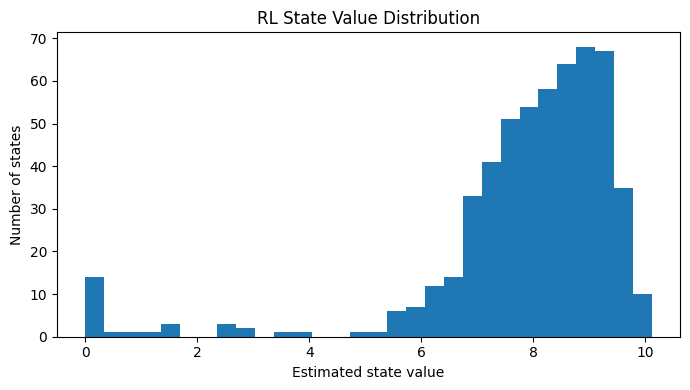

In [14]:
# --------------------------------------------------
# Section 14 — State value landscape
# --------------------------------------------------

display(policy_df["state_value"].describe().round(3))

plt.figure(figsize=(7, 4))
plt.hist(policy_df["state_value"], bins=30)
plt.xlabel("Estimated state value")
plt.ylabel("Number of states")
plt.title("RL State Value Distribution")
plt.tight_layout()
plt.show()

## Section 15 — Highest-value and lowest-value states

This section identifies the best and worst cellular states learned by the RL agent.

The highest-value states represent favorable manufacturing conditions.

The lowest-value states represent states where process intervention may be difficult or where the digital twin expects poor long-term outcomes.

In [15]:
# --------------------------------------------------
# Section 15 — Highest-value and lowest-value states
# --------------------------------------------------

top_states = policy_df.sort_values("state_value", ascending=False).head(20)
bottom_states = policy_df.sort_values("state_value", ascending=True).head(20)

print("Top-value states:")
display(top_states)

print("Bottom-value states:")
display(bottom_states)

Top-value states:


,rl_state,best_action,state_value
433,P3_B0_R0_G3_O1,no_action,10.114565
462,P3_B1_R0_G3_O1,no_action,9.988651
432,P3_B0_R0_G3_O0,adaptive_feed,9.925533
294,P2_B0_R1_G3_O1,adaptive_feed,9.924091
313,P2_B1_R0_G3_O1,adaptive_feed,9.847518
476,P3_B1_R1_G3_O1,mild_temp_shift,9.842517
461,P3_B1_R0_G3_O0,stress_mitigation,9.840375
430,P3_B0_R0_G2_O1,no_action,9.837601
446,P3_B0_R1_G3_O1,stress_mitigation,9.808705
429,P3_B0_R0_G2_O0,mild_temp_shift,9.782842


Bottom-value states:


,rl_state,best_action,state_value
144,P1_B0_R0_G3_O2,no_action,0.000000
346,P2_B1_R3_G1_O1,no_action,0.000000
350,P2_B1_R3_G3_O1,no_action,0.000000
171,P1_B1_R0_G3_O2,no_action,0.000000
541,P3_B3_R3_G0_O1,no_action,0.000000
175,P1_B1_R1_G0_O3,no_action,0.000000
492,P3_B1_R3_G3_O3,no_action,0.000000
27,P0_B1_R0_G1_O2,no_action,0.000000
464,P3_B1_R1_G0_O0,no_action,0.000000
204,P1_B1_R3_G3_O1,no_action,0.000000


## Section 16 — Attach learned policy back to trajectory states

This section maps the learned RL action back onto each Notebook14v2 trajectory row.

This lets us compare:

- action originally used in Notebook14v2
- action recommended by RL

This step is important for biological interpretation.

In [16]:
# --------------------------------------------------
# Section 16 — Attach learned policy back to trajectory states
# --------------------------------------------------

trajectory_rl = trajectory_rl.merge(
    policy_df,
    on="rl_state",
    how="left"
)

display(
    trajectory_rl[
        [
            "clone_process_id",
            "policy",
            "pseudo_time",
            "action",
            "best_action",
            "reward",
            "rl_state",
        ]
        + (["regime_name"] if "regime_name" in trajectory_rl.columns else [])
    ].head()
)

,clone_process_id,policy,pseudo_time,action,best_action,reward,rl_state,regime_name
0,0,adaptive_feed,0,no_action,perfusion_rescue,0.346667,P3_B3_R3_G1_O3,Stress_HighRisk
1,0,adaptive_feed,1,no_action,perfusion_rescue,0.322897,P3_B3_R3_G1_O3,Stress_HighRisk
2,0,adaptive_feed,2,no_action,perfusion_rescue,0.301309,P3_B3_R3_G1_O3,Stress_HighRisk
3,0,adaptive_feed,3,no_action,perfusion_rescue,0.280606,P3_B3_R3_G1_O3,Stress_HighRisk
4,0,adaptive_feed,4,adaptive_feed,perfusion_rescue,0.257557,P3_B3_R3_G1_O3,Stress_HighRisk


## Section 17 — Learned policy by dynamic regime

Notebook14v2 assigned each dynamic state to a biological regime.

This section asks:

Which RL actions are recommended in each dynamic regime?

This helps convert the learned policy from abstract Q-values into biological process logic.

In [17]:
# --------------------------------------------------
# Section 17 — Learned policy by dynamic regime
# --------------------------------------------------

if "regime_name" in trajectory_rl.columns:
    regime_action_table = (
        trajectory_rl
        .groupby(["regime_name", "best_action"])
        .size()
        .reset_index(name="count")
        .pivot(index="regime_name", columns="best_action", values="count")
        .fillna(0)
        .astype(int)
    )

    display(regime_action_table)

    regime_action_frac = regime_action_table.div(
        regime_action_table.sum(axis=1),
        axis=0
    )

    display(regime_action_frac.round(3))
else:
    print("regime_name column not available.")

best_action,adaptive_feed,mild_temp_shift,no_action,perfusion_rescue,stress_mitigation
regime_name,,,,,
Adaptive_Quality,593,475,325,649,427
Burdened_LowQuality,367,446,455,1356,556
Productive_Rescued,981,422,356,65,170
Stress_HighRisk,7,135,20,468,7


best_action,adaptive_feed,mild_temp_shift,no_action,perfusion_rescue,stress_mitigation
regime_name,,,,,
Adaptive_Quality,0.240,0.192,0.132,0.263,0.173
Burdened_LowQuality,0.115,0.140,0.143,0.426,0.175
Productive_Rescued,0.492,0.212,0.179,0.033,0.085
Stress_HighRisk,0.011,0.212,0.031,0.735,0.011


## Section 18 — Compare RL recommendations with Notebook14v2 actions

This section compares the action originally used in the simulated trajectory against the action learned by RL.

Agreement means the RL policy often recommends the same action as the original policy.

Disagreement may suggest that the learned policy sees a better alternative.

Overall RL/logged action match rate: 0.204


policy
rule_based           0.280
adaptive_feed        0.228
perfusion_rescue     0.207
stress_mitigation    0.189
mild_temp_shift      0.165
no_action            0.157
Name: rl_matches_logged_action, dtype: float64

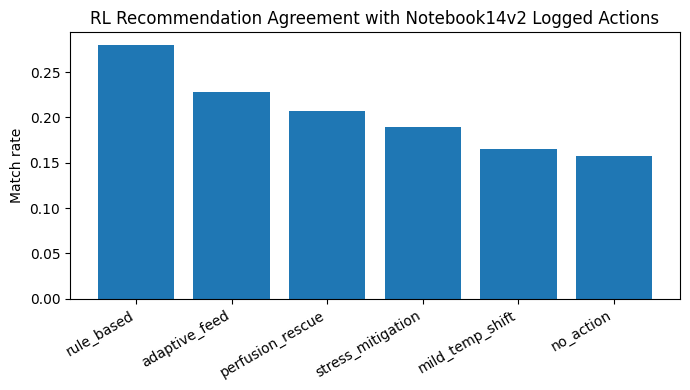

In [18]:
# --------------------------------------------------
# Section 18 — Compare RL recommendations with Notebook14v2 actions
# --------------------------------------------------

trajectory_rl["rl_matches_logged_action"] = (
    trajectory_rl["action"] == trajectory_rl["best_action"]
)

match_rate = trajectory_rl["rl_matches_logged_action"].mean()

print("Overall RL/logged action match rate:", round(match_rate, 3))

match_by_policy = (
    trajectory_rl
    .groupby("policy")["rl_matches_logged_action"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

display(match_by_policy)

plt.figure(figsize=(7, 4))
plt.bar(match_by_policy.index, match_by_policy.values)
plt.ylabel("Match rate")
plt.title("RL Recommendation Agreement with Notebook14v2 Logged Actions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Section 19 — Compare reward of original policies

This section re-summarizes the original Notebook14v2 policy performance.

This provides the baseline context for interpreting the learned RL policy.

,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden
policy,,,,,,,
rule_based,0.232,0.252,0.234,0.287,0.753,0.688,0.344
perfusion_rescue,0.231,0.121,0.115,0.209,0.723,0.678,0.115
mild_temp_shift,0.219,0.071,0.190,0.271,0.817,0.752,0.225
stress_mitigation,0.216,0.104,0.184,0.237,0.778,0.688,0.218
adaptive_feed,0.207,0.222,0.238,0.342,0.717,0.671,0.339
no_action,0.188,0.094,0.185,0.331,0.720,0.672,0.221


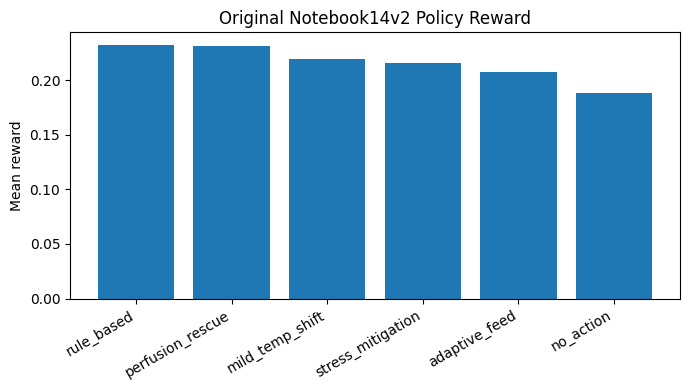

In [19]:
# --------------------------------------------------
# Section 19 — Original Notebook14v2 policy reward comparison
# --------------------------------------------------

logged_policy_summary = (
    trajectory_rl
    .groupby("policy")[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
            "overflow_burden",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("reward", ascending=False)
)

display(logged_policy_summary)

plt.figure(figsize=(7, 4))
plt.bar(logged_policy_summary.index, logged_policy_summary["reward"])
plt.ylabel("Mean reward")
plt.title("Original Notebook14v2 Policy Reward")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Section 20 — Estimate RL policy value using logged-state approximation

A true RL evaluation would require rolling out the learned policy in the simulator.

In this notebook, we perform a simple offline approximation:

For each RL state, we estimate the average reward historically observed when the learned action was taken.

This is not a perfect off-policy evaluation.

However, it gives an initial sanity check of whether the learned policy selects actions associated with higher rewards in the logged simulation data.

,strategy,mean_reward
0,RL_policy_logged_state_approx,0.229
1,rule_based_logged,0.237
2,overall_logged,0.220


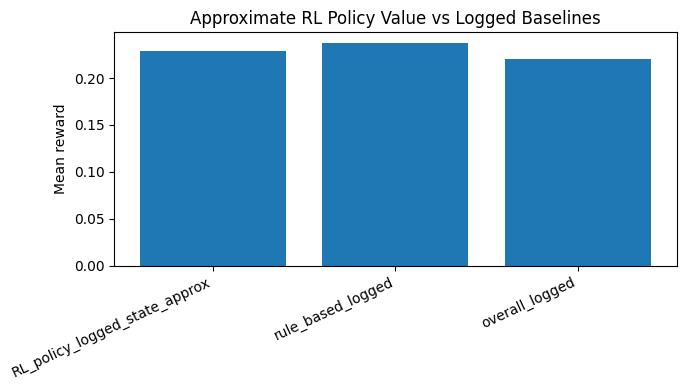

In [20]:
# --------------------------------------------------
# Section 20 — Offline logged-state approximation of RL policy value
# --------------------------------------------------

state_action_reward = (
    transitions_df
    .groupby(["state", "action"])["reward"]
    .mean()
    .reset_index()
    .rename(columns={"reward": "mean_logged_reward"})
)

policy_eval = policy_df.merge(
    state_action_reward,
    left_on=["rl_state", "best_action"],
    right_on=["state", "action"],
    how="left"
)

rl_logged_value = policy_eval["mean_logged_reward"].mean()

rule_based_logged_value = (
    transitions_df
    .loc[transitions_df["policy"] == "rule_based", "reward"]
    .mean()
)

overall_logged_value = transitions_df["reward"].mean()

comparison = pd.DataFrame({
    "strategy": [
        "RL_policy_logged_state_approx",
        "rule_based_logged",
        "overall_logged",
    ],
    "mean_reward": [
        rl_logged_value,
        rule_based_logged_value,
        overall_logged_value,
    ]
}).round(3)

display(comparison)

plt.figure(figsize=(7, 4))
plt.bar(comparison["strategy"], comparison["mean_reward"])
plt.ylabel("Mean reward")
plt.title("Approximate RL Policy Value vs Logged Baselines")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Section 21 — Export Notebook15 outputs

This section saves the learned RL policy and summary outputs.

These files can be used later for:

- policy interpretation
- digital twin control logic
- Notebook16 rollout simulation
- future dashboard development

In [21]:
# --------------------------------------------------
# Section 21 — Export Notebook15 outputs
# --------------------------------------------------

OUT_DIR = (
    ROOT
    / "data"
    / "synthetic"
    / "digital_twin"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY_PATH = (
    OUT_DIR
    / f"notebook15_rl_policy_{n_clones}_{scenario}.csv"
)

TRAJECTORY_WITH_POLICY_PATH = (
    OUT_DIR
    / f"notebook15_trajectory_with_rl_policy_{n_clones}_{scenario}.csv"
)

COMPARISON_PATH = (
    OUT_DIR
    / f"notebook15_policy_value_comparison_{n_clones}_{scenario}.csv"
)

POLICY_ACTION_BY_REGIME_PATH = (
    OUT_DIR
    / f"notebook15_rl_action_by_regime_{n_clones}_{scenario}.csv"
)

policy_df.to_csv(POLICY_PATH, index=False)
trajectory_rl.to_csv(TRAJECTORY_WITH_POLICY_PATH, index=False)
comparison.to_csv(COMPARISON_PATH, index=False)

if "regime_name" in trajectory_rl.columns:
    regime_action_frac.to_csv(POLICY_ACTION_BY_REGIME_PATH)

print("Saved:")
print(POLICY_PATH)
print(TRAJECTORY_WITH_POLICY_PATH)
print(COMPARISON_PATH)

if "regime_name" in trajectory_rl.columns:
    print(POLICY_ACTION_BY_REGIME_PATH)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook15_rl_policy_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook15_trajectory_with_rl_policy_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook15_policy_value_comparison_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook15_rl_action_by_regime_5000_legacy.csv


# Final Summary — Notebook15

Notebook15 introduced an offline reinforcement-learning prototype for the CHO digital twin.

Notebook14v2 created dynamic cellular trajectories with:

state → action → transition → reward

Notebook15 used those trajectories to learn:

state → best action

---

## What was achieved

This notebook:

- loaded Notebook14v2 dynamic trajectory data
- defined RL state variables
- discretized continuous biological states
- constructed an offline transition dataset
- trained a Q-learning model
- extracted a learned intervention policy
- interpreted learned actions by biological regime
- compared RL recommendations with logged Notebook14v2 actions
- exported the learned policy

---

## Biological interpretation

The learned policy represents a virtual process-control strategy.

It recommends actions such as:

- adaptive_feed
- mild_temp_shift
- perfusion_rescue
- stress_mitigation
- no_action

based on the current cellular state.

This creates the first version of a decision-support layer for the CHO digital twin.

---

## Why this matters

Earlier notebooks answered:

Which clone is good?

Which process condition is good?

Which clone-process candidates are Pareto optimal?

Notebook15 asks:

Given the current cellular state, what should we do next?

This is a major step toward:

- autonomous process optimization
- self-driving laboratory simulation
- digital twin control
- reinforcement-learning-guided biologics manufacturing

---

## Important limitations

This is still an offline RL prototype.

The model learns only from synthetic trajectories generated in Notebook14v2.

It does not yet perform true simulator rollouts under the learned policy.

The next major improvement is to use the learned policy to actively simulate new trajectories.

That should become Notebook16.

---

## Recommended next step

Notebook16 should perform learned-policy rollout simulation.

That means:

initial cellular state
→ RL chooses action
→ simulator applies transition
→ reward is observed
→ repeat over pseudo-time

This would allow direct comparison between:

- no_action
- rule_based
- RL_learned_policy

and would show whether the learned policy truly improves long-term process performance.

# References

1. Sutton RS, Barto AG. Reinforcement Learning: An Introduction. MIT Press.

2. Powell WB. Approximate Dynamic Programming: Solving the Curses of Dimensionality.

3. Ernst D, Geurts P, Wehenkel L. Tree-based batch mode reinforcement learning.

4. Levine S, Kumar A, Tucker G, Fu J. Offline Reinforcement Learning: Tutorial, Review, and Perspectives.

5. Shahriari B et al. Taking the Human Out of the Loop: A Review of Bayesian Optimization.

6. NISTCHO Cell Line and related CHO reference resources.

7. Systems biology and digital twin approaches for mammalian cell culture process optimization.